In [4]:
# --- CELL 1: THE REALISTIC CLEANING & CHURN SIMULATION ---
import pandas as pd
import numpy as np
import time

file_path = "C:\\Users\\rouna\\OneDrive\\Desktop\\Projects\\Railway Ml model\\csv files\\Railway Ticket Confirmation.csv"
df = pd.read_csv(file_path)

start_time = time.time()

# 1. SAFE DROP
cols_to_drop = ['PNR Number', 'Current Status', 'Confirmation Status'] # Drop the rigged target
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 2. DATE MATH
df['Booking Date'] = pd.to_datetime(df['Booking Date'], errors='coerce')
df['Date of Journey'] = pd.to_datetime(df['Date of Journey'], errors='coerce')
df['Days_to_Departure'] = (df['Date of Journey'] - df['Booking Date']).dt.days
df = df.drop(columns=[col for col in ['Booking Date', 'Date of Journey'] if col in df.columns])

# 3. THE HARDCORE WAITLIST FILTER
if 'Waitlist Position' in df.columns:
    df['Waitlist Position'] = df['Waitlist Position'].astype(str).str.extract(r'(\d+)').astype(float)
    df = df.dropna(subset=['Waitlist Position'])
    df = df[df['Waitlist Position'] > 0]

# 4. INJECTING REALITY: SYNTHETIC CHURN SIMULATION
# We mathematically simulate the waitlist clearing based on real-world logic
np.random.seed(42) # Ensure we get the same results every time

def simulate_clearing(row):
    # Base probability drops as waitlist position gets higher
    prob = max(0, 100 - (row['Waitlist Position'] * 2))
    # Bonus probability if booked far in advance
    prob += (row['Days_to_Departure'] * 0.5)
    
    # Cap probability between 5% and 95%
    prob = min(95, max(5, prob))
    
    # Randomly clear the ticket based on the calculated probability
    return 1 if np.random.uniform(0, 100) <= prob else 0

# Create our new, realistic target variable
df['Is_Confirmed'] = df.apply(simulate_clearing, axis=1)

print(f"Realistic Target Created! Confirmed Waitlists: {df['Is_Confirmed'].sum()} out of {df.shape[0]}")

# 5. ONE-HOT ENCODE & FORMAT FOR XGBOOST
text_columns = df.select_dtypes(include=['object']).columns.tolist()
if len(text_columns) > 0:
    df = pd.get_dummies(df, columns=text_columns, drop_first=False)

bool_cols = df.select_dtypes(include=['bool']).columns
if len(bool_cols) > 0:
    df[bool_cols] = df[bool_cols].astype(int)

end_time = time.time()
print(f"Pipeline Complete! Time taken: {round(end_time - start_time, 3)} seconds")

Realistic Target Created! Confirmed Waitlists: 9577 out of 10053
Pipeline Complete! Time taken: 0.189 seconds


In [5]:
# --- CELL 2: TRAIN / TEST SPLIT ---
from sklearn.model_selection import train_test_split

# Separate the Features (X) from the Target (y)
X = df.drop('Is_Confirmed', axis=1)
y = df['Is_Confirmed']

# Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data: {X_train.shape[0]} tickets")
print(f"Testing Data: {X_test.shape[0]} tickets")

Training Data: 8042 tickets
Testing Data: 2011 tickets


In [6]:
# --- CELL 3: MODEL TRAINING ---
from xgboost import XGBClassifier
import time

# Initialize the algorithm
model = XGBClassifier(random_state=42, eval_metric='logloss')

print("Starting training...")
start_time = time.time()

# Train the model
model.fit(X_train, y_train)

end_time = time.time()
print(f"Training Complete! Time taken: {round(end_time - start_time, 3)} seconds.")

Starting training...
Training Complete! Time taken: 0.288 seconds.


Realistic Model Accuracy: 94.83%

Classification Report:
                precision    recall  f1-score   support

Waitlisted (0)       0.00      0.00      0.00       102
 Confirmed (1)       0.95      1.00      0.97      1909

      accuracy                           0.95      2011
     macro avg       0.47      0.50      0.49      2011
  weighted avg       0.90      0.95      0.92      2011



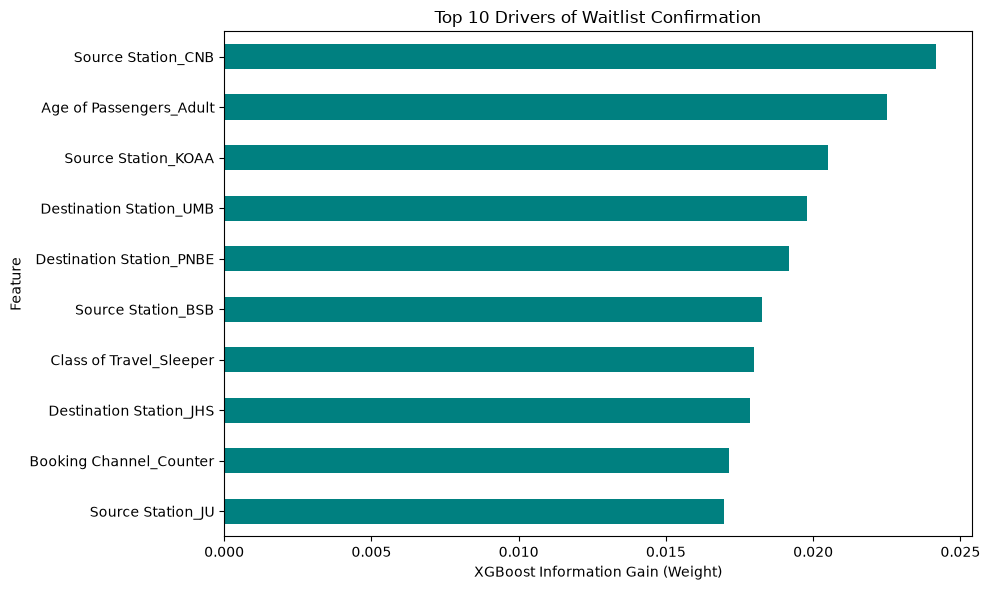

In [7]:
# --- CELL 4: EVALUATION & INSIGHTS (REALISTIC) ---
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# 1. Make Predictions on the hidden 20%
y_pred = model.predict(X_test)

# 2. Grade the Exam (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Realistic Model Accuracy: {accuracy * 100:.2f}%\n")

# 3. Detailed Report (Precision & Recall)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Waitlisted (0)', 'Confirmed (1)']))

# 4. Visualize Algorithmic Weighting (Feature Importance)
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)
top_10_features = feature_importances.nlargest(10)

plt.figure(figsize=(10, 6))
top_10_features.sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Drivers of Waitlist Confirmation')
plt.xlabel('XGBoost Information Gain (Weight)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()